# Connect drive

In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Install YOLOv11
!pip install ultralytics

from ultralytics import YOLO
import os

# Verify these paths in 'data.yaml' (located in the left sidebar):
# train: /content/drive/MyDrive/DL - Final/yolo/datasets/train/images
# val: /content/drive/MyDrive/DL - Final/yolo/datasets/valid/images
# test: /content/drive/MyDrive/DL - Final/yolo/datasets/test/images

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# With Data augumentation


In [ ]:
# 3. Path Definitions
# Note: Python handles spaces in paths well, but double-check your 'data.yaml' formatting.
yaml_path = '/content/drive/MyDrive/DL - Final/yolo/datasets/data.yaml'
save_project_path = '/content/drive/MyDrive/DL - Final/yolo/runs'

# 4. Load Model
# Switched to yolo11s.pt for better accuracy (optimized for A100 GPU).
model = YOLO('yolo11s.pt')

# 5. Start Training (A100 Optimized)
model.train(
    data=yaml_path,
    project=save_project_path,
    epochs=200,
    imgsz=640,
    batch=64,             # High batch size for A100 memory efficiency
    workers=8,            # Increased data loading threads
    device=0,             # Use GPU
    name='Classified_with_DA_200',

    # --- Spatial Augmentation (Handling overlapping/multiple objects) ---
    mosaic=1.0,           # 4-image tiling to force multi-object learning
    mixup=0.1,            # Image blending for noise robustness
    degrees=20.0,         # Rotation up to 20 degrees
    translate=0.1,        # Random translation (shifts)
    scale=0.5,            # Random scaling (0.5x to 1.5x)
    fliplr=0.5,           # 50% chance horizontal flip

    # --- Color & Lighting (Crucial for ripeness detection) ---
    hsv_h=0.015,          # Subtle hue shifts
    hsv_s=0.7,            # Significant saturation variation
    hsv_v=0.4,            # Brightness variation for different lighting conditions

    # --- Advanced Strategy ---
    # copy_paste=0.3,     # Good for multi-object samples if using segmentation
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DL - Final/yolo/datasets/data.yaml, degrees=20.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Classified_with_DA_200, nbs=64, nms=False, opset=None, optimize=False, opt

KeyboardInterrupt: 

# No Data augumentation


In [ ]:
yaml_path = '/content/drive/MyDrive/DL - Final/yolo/datasets/data.yaml'
save_project_path = '/content/drive/MyDrive/DL - Final/yolo/runs'

# 4. Load Model
# Using yolo11s.pt for higher precision, optimized for A100 performance.
model = YOLO('yolo11s.pt')

# 5. Start Training (A100 Optimized Baseline)
model.train(
    data=yaml_path,
    project=save_project_path,
    epochs=100,
    imgsz=640,
    batch=64,
    workers=8,
    device=0,
    name='fruit_ripeness_baseline',

    # --- Disable all Data Augmentation ---
    mosaic=0.0,          # Disable 4-image tiling
    fliplr=0.0,          # Disable horizontal flip
    flipud=0.0,          # Disable vertical flip
    hsv_h=0.0,           # Disable hue adjustment
    hsv_s=0.0,           # Disable saturation adjustment
    hsv_v=0.0,           # Disable value (brightness) adjustment
    degrees=0.0,         # Disable rotation
    translate=0.0,       # Disable translation
    scale=0.0,           # Disable scaling
    shear=0.0,           # Disable shearing
    perspective=0.0,     # Disable perspective transformation
    copy_paste=0.0,      # Disable copy-paste augmentation
    mixup=0.0,           # Disable mixup augmentation
    auto_augment=None,   # Disable automatic augmentation strategies
    erasing=0.0,         # Disable random erasing
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DL - Final/yolo/datasets/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=fruit_ripness_baseline2, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x780eca7636b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,   

# Redraw chart


✅ 繪圖完成！請查看雲端資料夾：
➡️ /content/drive/MyDrive/DL - Final/yolo/runs/Classified_with_DA/DA.png


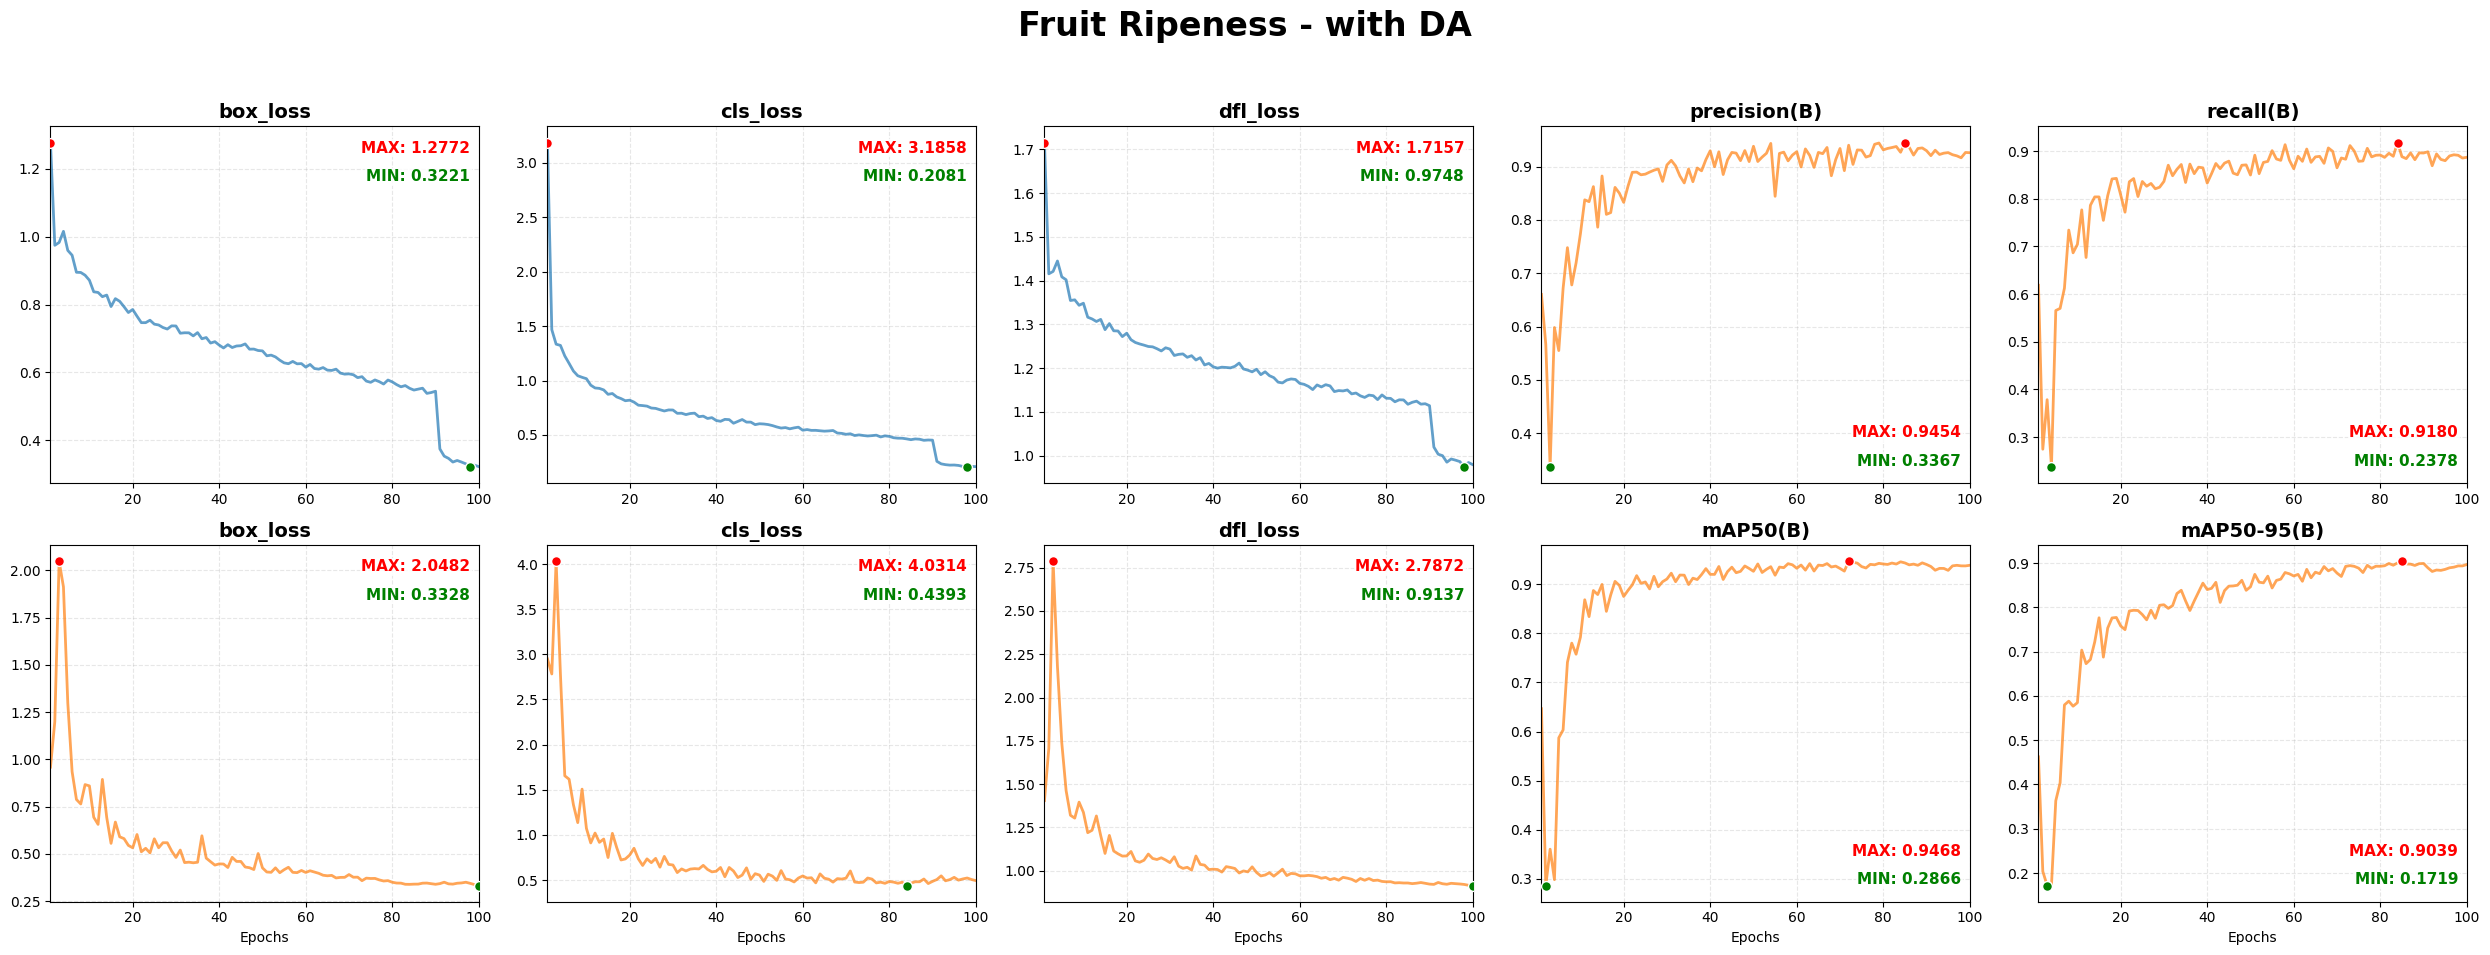

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Path Configuration
# Toggle these paths depending on which result you are analyzing (DA vs Baseline)
csv_path = '/content/drive/MyDrive/DL - Final/yolo/runs/Classified_with_DA/results.csv'
# csv_path = '/content/drive/MyDrive/DL - Final/yolo/runs/fruit_ripeness_baseline/results.csv'

save_dir = os.path.dirname(csv_path)
save_path = os.path.join(save_dir, 'DA_results.png')
# save_path = os.path.join(save_dir, 'Baseline_results.png')

if not os.path.exists(csv_path):
    print(f"❌ CSV file not found: {csv_path}")
else:
    # Load data and clean column names (remove leading/trailing spaces)
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    epochs = df['epoch']

    # Define the 10 core metrics for visualization
    metrics = [
        'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)',
        'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)'
    ]

    # Initialize Plot
    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    fig.suptitle('Fruit Ripeness Training Analysis - with DA', fontsize=24, fontweight='bold', y=0.98)
    # fig.suptitle('Fruit Ripeness Training Analysis - Baseline (No DA)', fontsize=24, fontweight='bold', y=0.98)

    for i, metric in enumerate(metrics):
        row, col = divmod(i, 5)
        ax = axes[row, col]

        if metric in df.columns:
            values = df[metric]
            max_val, min_val = values.max(), values.min()
            max_ep, min_ep = epochs[values.idxmax()], epochs[values.idxmin()]

            # --- Plot Main Curves ---
            line_color = 'tab:blue' if 'train' in metric else 'tab:orange'
            ax.plot(epochs, values, color=line_color, linewidth=2, alpha=0.7)

            # --- Mark Extremes (Red for Max, Green for Min) ---
            ax.scatter(max_ep, max_val, color='red', s=50, zorder=10, edgecolors='white')
            ax.scatter(min_ep, min_val, color='green', s=50, zorder=10, edgecolors='white')

            # --- Label Positioning Logic ---
            tx = 0.98  # Align text to the right side of the subplot

            if 'loss' in metric.lower():
                # Loss Metrics: Place labels at Top-Right
                ty_max, ty_min = 0.96, 0.88
                va = 'top'
            else:
                # Performance Metrics: Place labels at Bottom-Right
                ty_max, ty_min = 0.12, 0.04
                va = 'bottom'

            # Annotate MAX value
            ax.text(tx, ty_max, f'MAX: {max_val:.4f}', transform=ax.transAxes,
                    color='red', fontweight='bold', ha='right', va=va, fontsize=11,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

            # Annotate MIN value
            ax.text(tx, ty_min, f'MIN: {min_val:.4f}', transform=ax.transAxes,
                    color='green', fontweight='bold', ha='right', va=va, fontsize=11,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

            # Subplot Aesthetics
            ax.set_title(metric.split('/')[-1], fontsize=14, fontweight='bold')
            ax.grid(True, linestyle='--', alpha=0.3)
            ax.set_xlim(epochs.min(), epochs.max())
            if row == 1: ax.set_xlabel('Epochs', fontsize=10)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Save and Export
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Plotting complete! File saved at:\n➡️ {save_path}")
    plt.show()